In [1]:
import pyFAI
import h5py, hdf5plugin
import numpy as np
import matplotlib.pyplot as plt
import pyFAI.opencl as cl

In [2]:
ai = pyFAI.load("/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/process/LaB6_35keV_599p927mm.poni")

In [3]:
path_scans = '/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/raw/xrd_ct_overview/'
filename = 'scan-0339_pilatus.h5'

projection_idx = 0
with h5py.File(path_scans + filename, 'r') as f:
    dataset = f['entry/instrument/pilatus/data']
    data = dataset[362 * projection_idx : 362 * projection_idx + 362]

In [4]:
print(cl.ocl)

OpenCL devices:
[0] NVIDIA CUDA: (0,0) NVIDIA A100-PCIE-40GB


In [ ]:
for i in range(10):

    res = ai.integrate2d(
        data[150],
        npt_rad=150,
        npt_azim=360,
        radial_range=(8.0, 40.0),
        method=("no", "csr", "opencl"),
        #unit="2th_deg",
    )


intensity = res.intensity     # shape (npt_azim, npt_rad)
rad = res.radial        # 1D array
chi = res.azimuthal           # 1D array


In [17]:
print(rad)

[ 8.12333335  8.37000005  8.61666676  8.86333346  9.11000016  9.35666686
  9.60333357  9.85000027 10.09666697 10.34333367 10.59000038 10.83666708
 11.08333378 11.33000048 11.57666719 11.82333389 12.07000059 12.31666729
 12.56333399 12.8100007  13.0566674  13.3033341  13.5500008  13.79666751
 14.04333421 14.29000091 14.53666761 14.78333432 15.03000102 15.27666772
 15.52333442 15.77000113 16.01666783 16.26333453 16.51000123 16.75666794
 17.00333464 17.25000134 17.49666804 17.74333475 17.99000145 18.23666815
 18.48333485 18.73000156 18.97666826 19.22333496 19.47000166 19.71666837
 19.96333507 20.21000177 20.45666847 20.70333518 20.95000188 21.19666858
 21.44333528 21.69000198 21.93666869 22.18333539 22.43000209 22.67666879
 22.9233355  23.1700022  23.4166689  23.6633356  23.91000231 24.15666901
 24.40333571 24.65000241 24.89666912 25.14333582 25.39000252 25.63666922
 25.88333593 26.13000263 26.37666933 26.62333603 26.87000274 27.11666944
 27.36333614 27.61000284 27.85666955 28.10333625 28

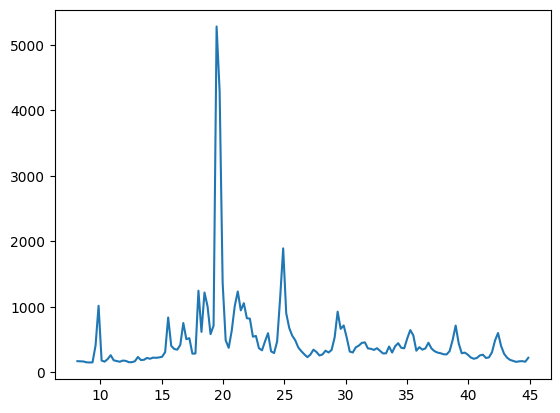

In [18]:
plt.plot(rad, intensity.sum(axis=0))

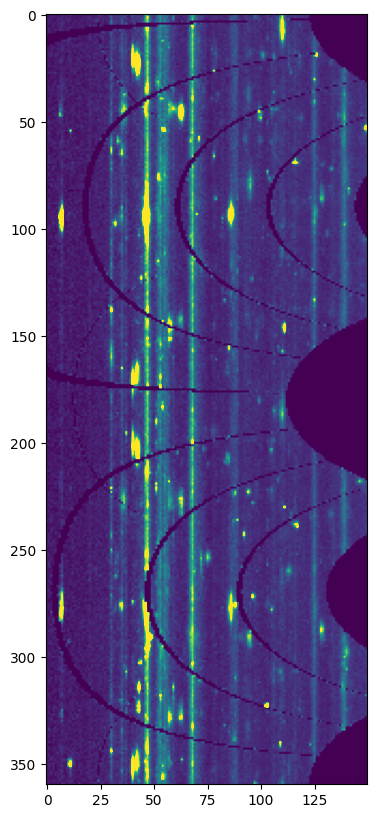

In [19]:
plt.figure(figsize=(20,10))
plt.imshow(intensity)
plt.clim([np.quantile(intensity,q=0.1),np.quantile(intensity, q=0.99) ])
plt.show()

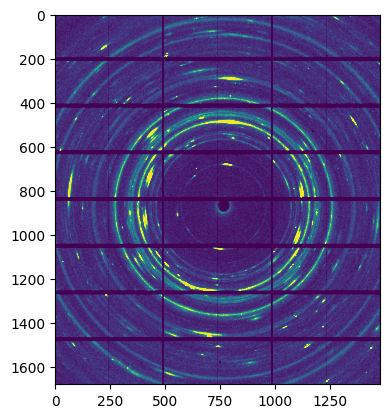

In [20]:
plt.imshow(data[150])
plt.clim([np.quantile(data[150],q=0.1),np.quantile(data[150], q=0.99) ])
plt.show()